# Notebook 3 — Random Forest Modeling & Validation
**Deadline:** Apr 26 (Weeks 11–13)  
**Goal:** Train Random Forest classifier, handle class imbalance, evaluate with time-series cross-validation (Brier Skill Score, AUC-ROC, CSI).

---

This notebook mirrors the **Hill et al. (2023) / CSU-MLP approach**:
- RandomForestClassifier (scikit-learn) — same architecture as operational CSU-MLP
- Time-series split: train 2021–2022, test 2023 (no data leakage)
- Class imbalance handled via `class_weight='balanced'` and optional SMOTE
- Skill evaluated vs. climatological baseline (Brier Skill Score)

In [2]:
# ============================================================
# IMPORTS & CONFIG
# ============================================================
import json
import warnings
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve, brier_score_loss,
    confusion_matrix, classification_report,
    average_precision_score, precision_recall_curve,
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")

# --- Config (Keeling-safe path) ---
PROJECT_ROOT = Path("~/Capstone2026/Testingthings").expanduser()
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
MODEL_DIR    = PROJECT_ROOT / "models"
OUTPUT_DIR   = PROJECT_ROOT / "outputs"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Imports OK.")
print("PROJECT_ROOT:", PROJECT_ROOT)

Imports OK.
PROJECT_ROOT: /data/keeling/a/tob3/Capstone2026/Testingthings


In [3]:
# ============================================================
# LOAD DATA
# Using synthetic data until real GEFS data is ready.
# Swap to "master_table.parquet" once Notebook 2 is complete.
# ============================================================

DATA_FILE = "master_table.parquet"

master = pd.read_parquet(DATA_PROC / DATA_FILE)

# Load feature schema
with open(DATA_PROC / "feature_schema.json") as f:
    schema = json.load(f)

LABEL_COL = schema["label_col"]

# Build FEATURE_COLS dynamically from what's actually in the master table
exclude_cols = ["fips", "valid_time_3h", "outage_event", "split",
                "land_area_km2", "STATEFP", "population"]
FEATURE_COLS = [c for c in master.columns if c not in exclude_cols]

# Update schema so Notebook 4 stays in sync
meta = {"feature_cols": FEATURE_COLS, "label_col": LABEL_COL,
        "data_file": "master_table.parquet"}
with open(DATA_PROC / "feature_schema.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"Features available: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

print(f"Master table: {master.shape}")
print(f"Outage rate: {master[LABEL_COL].mean()*100:.2f}%")
print(f"Features: {len(FEATURE_COLS)}")
master[["valid_time_3h", "fips", "outage_event"]].head()

Features available: 23
['ugrd_10m_mean', 'ugrd_10m_max', 'vgrd_10m_mean', 'vgrd_10m_max', 'apcp_sfc_mean', 'apcp_sfc_max', 'pwat_clm_mean', 'pwat_clm_max', 'rh_2m_mean', 'rh_2m_max', 'ugrd_shear_mean', 'vgrd_shear_mean', 'hlcy_3km_mean', 'cape_sfc_mean', 'cape_sfc_max', 'soilw_0_10_mean', 'soilw_0_10_max', 'forest_fraction', 'pop_density', 'wind_shear_mag_mean', 'wind_shear_mag_max', 'wind_speed_10m_mean', 'cape_x_shear']
Master table: (1677118, 28)
Outage rate: 12.08%
Features: 23


,valid_time_3h,fips,outage_event
0,2021-01-01,17001,1
1,2021-01-01,17019,0
2,2021-01-01,17021,0
3,2021-01-01,17031,0
4,2021-01-01,17037,0


In [4]:
# ============================================================
# TRAIN / TEST SPLIT (time-series split, not random)
# Train: 2021-2022 | Test: 2023
# ============================================================

train_mask = master["split"] == "train"
test_mask  = master["split"] == "test"

X_train = master.loc[train_mask, FEATURE_COLS].values
y_train = master.loc[train_mask, LABEL_COL].values
X_test  = master.loc[test_mask,  FEATURE_COLS].values
y_test  = master.loc[test_mask,  LABEL_COL].values

print(f"Train: {X_train.shape} | Outage rate: {y_train.mean()*100:.2f}%")
print(f"Test:  {X_test.shape}  | Outage rate: {y_test.mean()*100:.2f}%")

Train: (1104652, 23) | Outage rate: 12.42%
Test:  (572466, 23)  | Outage rate: 11.42%


---
## Class Imbalance Strategy

Outage events are rare (~1-3% of records). Two complementary approaches:

In [5]:
# ============================================================
# OPTION A: class_weight='balanced' (recommended first approach)
# Adjusts sample weights inversely proportional to class frequency.
# No data synthesis — safe for time-series.
# ============================================================

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,          # Hill et al. uses unlimited depth
    min_samples_leaf=5,
    max_features="sqrt",     # standard for classification
    class_weight="balanced", # handles imbalance
    n_jobs=-1,
    random_state=42,
    oob_score=True,          # free validation on training data
)

print("Fitting RF (balanced)...")
rf_balanced.fit(X_train, y_train)
print(f"OOB score: {rf_balanced.oob_score_:.4f}")
print("Done.")

Fitting RF (balanced)...
OOB score: 0.8821
Done.


In [6]:
# ============================================================
# OPTION B: SMOTE oversampling (use with caution for time-series)
# Better when positive class is very rare (<1%).
# Only apply SMOTE to TRAINING data — never to test set.
# ============================================================

APPLY_SMOTE = False   # <- toggle

if APPLY_SMOTE:
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print(f"After SMOTE: {X_train_res.shape} | Outage rate: {y_train_res.mean()*100:.2f}%")

    rf_smote = RandomForestClassifier(
        n_estimators=500, min_samples_leaf=5, max_features="sqrt",
        n_jobs=-1, random_state=42
    )
    rf_smote.fit(X_train_res, y_train_res)
    ACTIVE_MODEL = rf_smote
    print("Using SMOTE model.")
else:
    ACTIVE_MODEL = rf_balanced
    print("Using balanced class_weight model.")

Using balanced class_weight model.


---
## Evaluation

In [7]:
print("NaN counts per feature:")
print(master[FEATURE_COLS].isna().sum().sort_values(ascending=False))
print(f"\nRows with ANY NaN: {master[FEATURE_COLS].isna().any(axis=1).sum():,} / {len(master):,}")
print(f"Outage rate in train: {y_train.mean()*100:.3f}%")
print(f"Outage rate in test:  {y_test.mean()*100:.3f}%")

NaN counts per feature:


cape_x_shear           11791
cape_sfc_mean          11675
soilw_0_10_mean        11675
cape_sfc_max           11675
soilw_0_10_max         11675
vgrd_shear_mean         9723
ugrd_shear_mean         9723
wind_shear_mag_max      9723
wind_shear_mag_mean     9723
hlcy_3km_mean           9723
apcp_sfc_mean           9607
vgrd_10m_mean           9607
ugrd_10m_max            9607
ugrd_10m_mean           9607
vgrd_10m_max            9607
pwat_clm_mean           9607
apcp_sfc_max            9607
rh_2m_max               9607
pwat_clm_max            9607
rh_2m_mean              9607
wind_speed_10m_mean     9607
pop_density                0
forest_fraction            0
dtype: int64

Rows with ANY NaN: 11,791 / 1,677,118
Outage rate in train: 12.421%
Outage rate in test:  11.415%


In [8]:
# ============================================================
# SKILL SCORES — Hill et al. 2023 evaluation suite
# ============================================================

y_prob = ACTIVE_MODEL.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

# Brier Score + Brier Skill Score vs climatological baseline
climo_rate     = y_train.mean()
bs_model       = brier_score_loss(y_test, y_prob)
bs_climatology = brier_score_loss(y_test, np.full_like(y_prob, climo_rate))
bss = 1 - (bs_model / bs_climatology)

# AUC-ROC
auc = roc_auc_score(y_test, y_prob)

# Average Precision (better than AUC for imbalanced data)
ap = average_precision_score(y_test, y_prob)

# CSI (Critical Success Index) at 0.5 threshold
cm_ = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm_.ravel()
csi  = tp / (tp + fp + fn + 1e-8)
pod  = tp / (tp + fn + 1e-8)   # Probability of Detection
far  = fp / (tp + fp + 1e-8)   # False Alarm Ratio

print("\n" + "="*50)
print("  EVALUATION METRICS (vs 2023 holdout)")
print("="*50)
print(f"  Brier Score (model):      {bs_model:.4f}")
print(f"  Brier Score (climatology):{bs_climatology:.4f}")
print(f"  Brier Skill Score (BSS):  {bss:.4f}  {'✓ skill' if bss > 0 else '✗ no skill'}")
print(f"  AUC-ROC:                  {auc:.4f}")
print(f"  Average Precision (AP):   {ap:.4f}")
print(f"  CSI (threshold=0.5):      {csi:.4f}")
print(f"  POD:                      {pod:.4f}")
print(f"  FAR:                      {far:.4f}")
print("="*50)

metrics = {"BSS": bss, "AUC": auc, "AP": ap, "CSI": csi, "POD": pod, "FAR": far}
with open(OUTPUT_DIR / "03_model_metrics.json", "w") as f:
    json.dump({k: round(v, 4) for k, v in metrics.items()}, f, indent=2)


  EVALUATION METRICS (vs 2023 holdout)
  Brier Score (model):      0.0991
  Brier Score (climatology):0.1012
  Brier Skill Score (BSS):  0.0207  ✓ skill
  AUC-ROC:                  0.7308
  Average Precision (AP):   0.3461
  CSI (threshold=0.5):      0.1937
  POD:                      0.2433
  FAR:                      0.5126


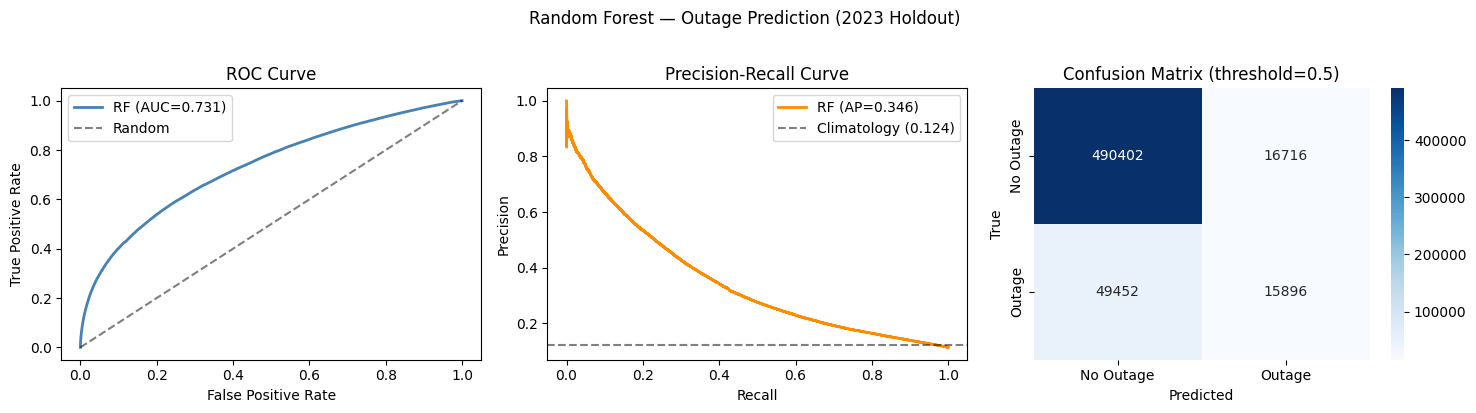

In [9]:
# ============================================================
# PLOTS: ROC curve + Precision-Recall + Confusion Matrix
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, lw=2, color="steelblue", label=f"RF (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend()

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec, prec, lw=2, color="darkorange", label=f"RF (AP={ap:.3f})")
axes[1].axhline(y=climo_rate, ls="--", color="k", alpha=0.5, label=f"Climatology ({climo_rate:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend()

# Confusion Matrix
sns.heatmap(cm_, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Outage", "Outage"],
            yticklabels=["No Outage", "Outage"], ax=axes[2])
axes[2].set_title("Confusion Matrix (threshold=0.5)")
axes[2].set_ylabel("True"); axes[2].set_xlabel("Predicted")

plt.suptitle("Random Forest — Outage Prediction (2023 Holdout)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

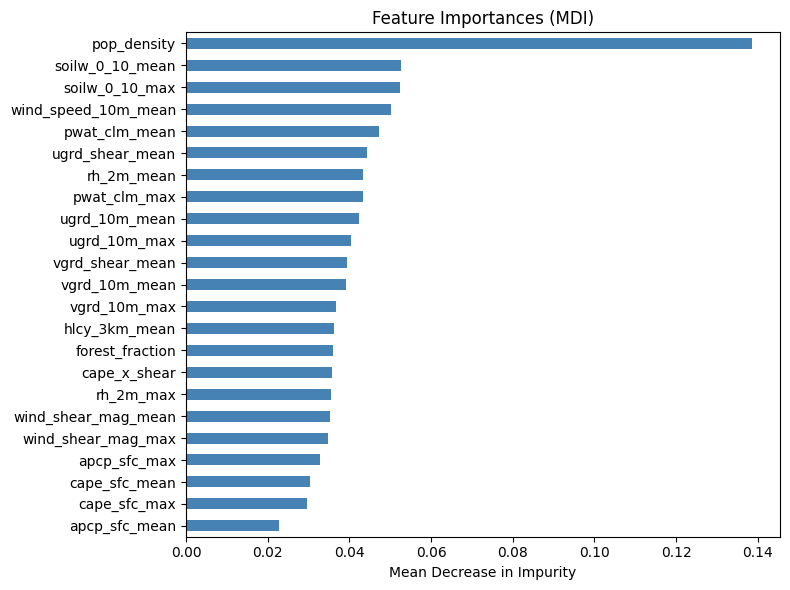


Top 5 features:
pop_density            0.138505
soilw_0_10_mean        0.052570
soilw_0_10_max         0.052469
wind_speed_10m_mean    0.050250
pwat_clm_mean          0.047254
dtype: float64


In [10]:
# ============================================================
# FEATURE IMPORTANCE (MDI — Mean Decrease in Impurity)
# ============================================================

importances = pd.Series(ACTIVE_MODEL.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature Importances (MDI)")
ax.set_xlabel("Mean Decrease in Impurity")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 features:")
print(importances.head())

In [11]:
# ============================================================
# SAVE MODEL
# ============================================================

joblib.dump(ACTIVE_MODEL, MODEL_DIR / "rf_outage_model.pkl")
print("Model saved to", MODEL_DIR / "rf_outage_model.pkl")
print("\n✅ Notebook 3 complete. Ready for 04_interpretability.ipynb")

Model saved to /data/keeling/a/tob3/Capstone2026/Testingthings/models/rf_outage_model.pkl

✅ Notebook 3 complete. Ready for 04_interpretability.ipynb
